<a href="https://colab.research.google.com/github/juzt-me/Hospital-Waiting-Time/blob/main/Hospital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving hospital_patient_waiting_times_100.csv to hospital_patient_waiting_times_100.csv


In [4]:
df = pd.read_csv("hospital_patient_waiting_times_100.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (100, 9)


In [5]:
df.head()

,Patient_ID,Department,Appointment_Time,Registration_Time,Consultation_Time,Discharge_Time,Doctor,Day,Appointment_Type
0,P046,Orthopedics,2026-08-03 08:00,2026-08-03 08:28,2026-08-03 08:58,2026-08-03 09:15,Dr. Ravi,Monday,Follow-up
1,P094,ENT,2026-08-03 08:00,2026-08-03 08:12,2026-08-03 08:17,2026-08-03 08:36,Dr. Vijay,Monday,Follow-up
2,P022,Orthopedics,2026-08-03 08:45,2026-08-03 09:03,2026-08-03 09:45,2026-08-03 10:07,Dr. Anitha,Monday,Regular
3,P069,Pediatrics,2026-08-03 10:00,2026-08-03 10:13,2026-08-03 10:35,2026-08-03 10:52,Dr. Divya,Monday,Walk-in
4,P020,General Medicine,2026-08-03 10:15,2026-08-03 10:34,2026-08-03 11:22,2026-08-03 11:46,Dr. Meena,Monday,Regular


In [6]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Patient_ID', 'Department', 'Appointment_Time', 'Registration_Time', 'Consultation_Time', 'Discharge_Time', 'Doctor', 'Day', 'Appointment_Type']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Patient_ID         100 non-null    object
 1   Department         100 non-null    object
 2   Appointment_Time   100 non-null    object
 3   Registration_Time  100 non-null    object
 4   Consultation_Time  100 non-null    object
 5   Discharge_Time     100 non-null    object
 6   Doctor             100 non-null    object
 7   Day                100 non-null    object
 8   Appointment_Type   100 non-null    object
dtypes: object(9)
memory usage: 7.2+ KB


In [8]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Patient_ID           0
Department           0
Appointment_Time     0
Registration_Time    0
Consultation_Time    0
Discharge_Time       0
Doctor               0
Day                  0
Appointment_Type     0
dtype: int64


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
time_columns = [
    'Appointment_Time',
    'Registration_Time',
    'Consultation_Time',
    'Discharge_Time'
]

for col in time_columns:
    df[col] = pd.to_datetime(df[col])

print("Timestamp conversion completed!")

Timestamp conversion completed!


In [11]:
print(df[time_columns].dtypes)

Appointment_Time     datetime64[ns]
Registration_Time    datetime64[ns]
Consultation_Time    datetime64[ns]
Discharge_Time       datetime64[ns]
dtype: object


In [12]:
df['Registration_Waiting'] = (
    df['Registration_Time'] - df['Appointment_Time']
).dt.total_seconds() / 60

In [13]:
df['Doctor_Waiting'] = (
    df['Consultation_Time'] - df['Registration_Time']
).dt.total_seconds() / 60

In [14]:
df['Total_Waiting'] = (
    df['Consultation_Time'] - df['Appointment_Time']
).dt.total_seconds() / 60

In [15]:
df['Consultation_Duration'] = (
    df['Discharge_Time'] - df['Consultation_Time']
).dt.total_seconds() / 60

In [16]:
df[
    [
        'Patient_ID',
        'Appointment_Time',
        'Registration_Time',
        'Consultation_Time',
        'Registration_Waiting',
        'Doctor_Waiting',
        'Total_Waiting',
        'Consultation_Duration'
    ]
].head(10)

,Patient_ID,Appointment_Time,Registration_Time,Consultation_Time,Registration_Waiting,Doctor_Waiting,Total_Waiting,Consultation_Duration
0,P046,2026-08-03 08:00:00,2026-08-03 08:28:00,2026-08-03 08:58:00,28.0,30.0,58.0,17.0
1,P094,2026-08-03 08:00:00,2026-08-03 08:12:00,2026-08-03 08:17:00,12.0,5.0,17.0,19.0
2,P022,2026-08-03 08:45:00,2026-08-03 09:03:00,2026-08-03 09:45:00,18.0,42.0,60.0,22.0
3,P069,2026-08-03 10:00:00,2026-08-03 10:13:00,2026-08-03 10:35:00,13.0,22.0,35.0,17.0
4,P020,2026-08-03 10:15:00,2026-08-03 10:34:00,2026-08-03 11:22:00,19.0,48.0,67.0,24.0
5,P024,2026-08-03 10:45:00,2026-08-03 11:18:00,2026-08-03 11:37:00,33.0,19.0,52.0,22.0
6,P052,2026-08-03 11:45:00,2026-08-03 11:58:00,2026-08-03 12:31:00,13.0,33.0,46.0,17.0
7,P062,2026-08-03 12:15:00,2026-08-03 12:31:00,2026-08-03 12:44:00,16.0,13.0,29.0,24.0
8,P070,2026-08-03 14:45:00,2026-08-03 15:12:00,2026-08-03 15:21:00,27.0,9.0,36.0,40.0
9,P078,2026-08-03 16:00:00,2026-08-03 16:13:00,2026-08-03 16:25:00,13.0,12.0,25.0,7.0


In [17]:
df[['Registration_Waiting',
    'Doctor_Waiting',
    'Total_Waiting',
    'Consultation_Duration']].describe()

,Registration_Waiting,Doctor_Waiting,Total_Waiting,Consultation_Duration
count,100.000000,100.00000,100.00000,100.000000
mean,17.680000,23.08000,40.76000,18.220000
std,9.517533,11.79512,16.02909,7.416307
min,2.000000,5.00000,7.00000,7.000000
25%,11.000000,14.75000,29.75000,13.000000
50%,17.000000,24.00000,41.50000,17.000000
75%,24.000000,31.25000,52.00000,23.000000
max,49.000000,52.00000,77.00000,43.000000


In [18]:
print("Average Registration Waiting:",
      df['Registration_Waiting'].mean(), "minutes")

print("Average Doctor Waiting:",
      df['Doctor_Waiting'].mean(), "minutes")

print("Average Total Waiting:",
      df['Total_Waiting'].mean(), "minutes")

print("Average Consultation Duration:",
      df['Consultation_Duration'].mean(), "minutes")

Average Registration Waiting: 17.68 minutes
Average Doctor Waiting: 23.08 minutes
Average Total Waiting: 40.76 minutes
Average Consultation Duration: 18.22 minutes


In [19]:
print("Negative Registration Waiting:",
      (df['Registration_Waiting'] < 0).sum())

print("Negative Doctor Waiting:",
      (df['Doctor_Waiting'] < 0).sum())

print("Negative Total Waiting:",
      (df['Total_Waiting'] < 0).sum())

print("Negative Consultation Duration:",
      (df['Consultation_Duration'] < 0).sum())

Negative Registration Waiting: 0
Negative Doctor Waiting: 0
Negative Total Waiting: 0
Negative Consultation Duration: 0


In [20]:
print("Departments:")
print(df['Department'].value_counts())

Departments:
Department
General Medicine    26
Pediatrics          17
Orthopedics         15
ENT                 14
Dermatology         14
Cardiology          14
Name: count, dtype: int64


In [21]:
department_analysis = df.groupby('Department').agg(
    Average_Waiting=('Total_Waiting', 'mean'),
    Median_Waiting=('Total_Waiting', 'median'),
    Maximum_Waiting=('Total_Waiting', 'max'),
    Patient_Count=('Patient_ID', 'count')
).sort_values('Average_Waiting', ascending=False)

department_analysis

,Average_Waiting,Median_Waiting,Maximum_Waiting,Patient_Count
Department,,,,
Cardiology,47.071429,45.0,74.0,14
General Medicine,43.846154,49.5,67.0,26
Orthopedics,43.400000,43.0,63.0,15
ENT,41.500000,44.5,77.0,14
Dermatology,38.571429,33.5,77.0,14
Pediatrics,29.705882,29.0,73.0,17


In [22]:
df['Day_Type'] = df['Day'].apply(
    lambda x: 'Weekend'
    if x in ['Saturday', 'Sunday']
    else 'Weekday'
)

print(df[['Day', 'Day_Type']].head(10))

      Day Day_Type
0  Monday  Weekday
1  Monday  Weekday
2  Monday  Weekday
3  Monday  Weekday
4  Monday  Weekday
5  Monday  Weekday
6  Monday  Weekday
7  Monday  Weekday
8  Monday  Weekday
9  Monday  Weekday


In [23]:
print(df['Day_Type'].value_counts())

Day_Type
Weekday    71
Weekend    29
Name: count, dtype: int64


In [24]:
day_analysis = df.groupby('Day_Type').agg(
    Average_Waiting=('Total_Waiting', 'mean'),
    Median_Waiting=('Total_Waiting', 'median'),
    Maximum_Waiting=('Total_Waiting', 'max'),
    Patient_Count=('Patient_ID', 'count')
)

day_analysis

,Average_Waiting,Median_Waiting,Maximum_Waiting,Patient_Count
Day_Type,,,,
Weekday,44.394366,44.0,77.0,71
Weekend,31.862069,31.0,77.0,29


In [25]:
print("Appointment Types:")
print(df['Appointment_Type'].value_counts())

Appointment Types:
Appointment_Type
Regular      43
Follow-up    25
Walk-in      20
Emergency    12
Name: count, dtype: int64


In [26]:
appointment_analysis = df.groupby('Appointment_Type').agg(
    Average_Waiting=('Total_Waiting', 'mean'),
    Median_Waiting=('Total_Waiting', 'median'),
    Maximum_Waiting=('Total_Waiting', 'max'),
    Patient_Count=('Patient_ID', 'count')
).sort_values('Average_Waiting', ascending=False)

appointment_analysis

,Average_Waiting,Median_Waiting,Maximum_Waiting,Patient_Count
Appointment_Type,,,,
Walk-in,49.850000,50.5,77.0,20
Emergency,48.000000,49.0,77.0,12
Regular,39.581395,41.0,74.0,43
Follow-up,32.040000,30.0,59.0,25


In [27]:
doctor_analysis = df.groupby('Doctor').agg(
    Average_Waiting=('Total_Waiting', 'mean'),
    Average_Doctor_Waiting=('Doctor_Waiting', 'mean'),
    Patient_Count=('Patient_ID', 'count')
).sort_values('Average_Waiting', ascending=False)

doctor_analysis

,Average_Waiting,Average_Doctor_Waiting,Patient_Count
Doctor,,,
Dr. Kumar,49.400000,26.400000,5
Dr. Anitha,48.333333,30.111111,9
Dr. Meena,46.437500,25.250000,16
Dr. Suresh,46.000000,26.800000,5
Dr. Priya,45.777778,34.888889,9
Dr. Lakshmi,44.625000,23.500000,8
Dr. Karthik,44.571429,27.428571,7
Dr. Arun,39.700000,19.400000,10
Dr. Vijay,37.333333,24.500000,6


In [28]:
day_of_week_analysis = df.groupby('Day').agg(
    Average_Waiting=('Total_Waiting', 'mean'),
    Patient_Count=('Patient_ID', 'count')
).sort_values('Average_Waiting', ascending=False)

day_of_week_analysis

,Average_Waiting,Patient_Count
Day,,
Wednesday,49.466667,15
Tuesday,46.800000,10
Monday,43.266667,15
Friday,41.882353,17
Thursday,41.500000,14
Sunday,34.076923,13
Saturday,30.062500,16


In [29]:
df['Appointment_Hour'] = df['Appointment_Time'].dt.hour

print(df[['Appointment_Time', 'Appointment_Hour']].head(10))

     Appointment_Time  Appointment_Hour
0 2026-08-03 08:00:00                 8
1 2026-08-03 08:00:00                 8
2 2026-08-03 08:45:00                 8
3 2026-08-03 10:00:00                10
4 2026-08-03 10:15:00                10
5 2026-08-03 10:45:00                10
6 2026-08-03 11:45:00                11
7 2026-08-03 12:15:00                12
8 2026-08-03 14:45:00                14
9 2026-08-03 16:00:00                16


In [30]:
hour_analysis = df.groupby('Appointment_Hour').agg(
    Average_Waiting=('Total_Waiting', 'mean'),
    Patient_Count=('Patient_ID', 'count')
).sort_values('Average_Waiting', ascending=False)

hour_analysis

,Average_Waiting,Patient_Count
Appointment_Hour,,
10,51.615385,13
11,47.307692,13
8,44.285714,7
9,42.562500,16
12,38.142857,14
15,35.583333,12
16,34.555556,9
14,32.937500,16


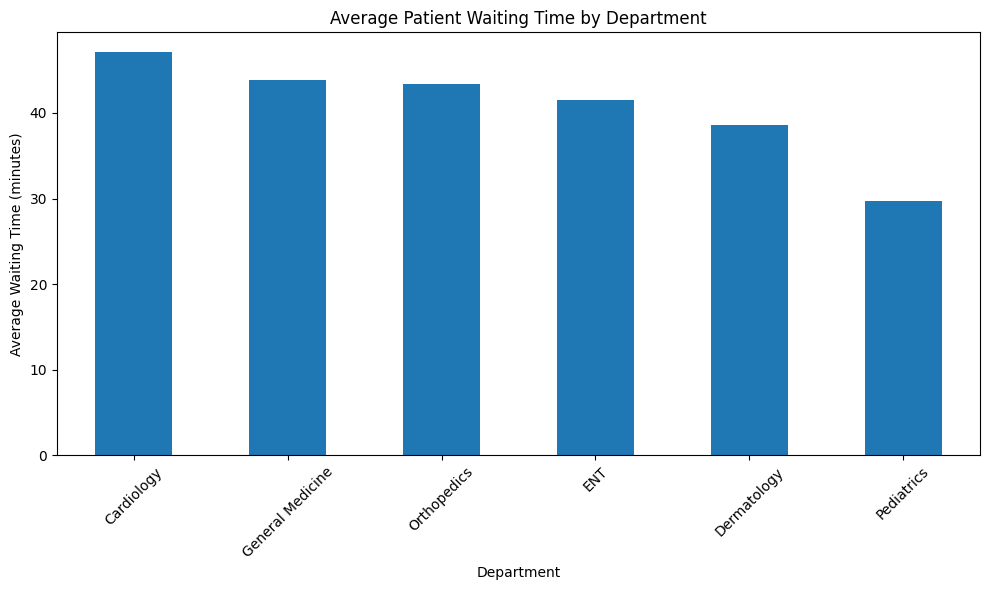

In [31]:
plt.figure(figsize=(10, 6))

department_analysis['Average_Waiting'].plot(kind='bar')

plt.title('Average Patient Waiting Time by Department')
plt.xlabel('Department')
plt.ylabel('Average Waiting Time (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

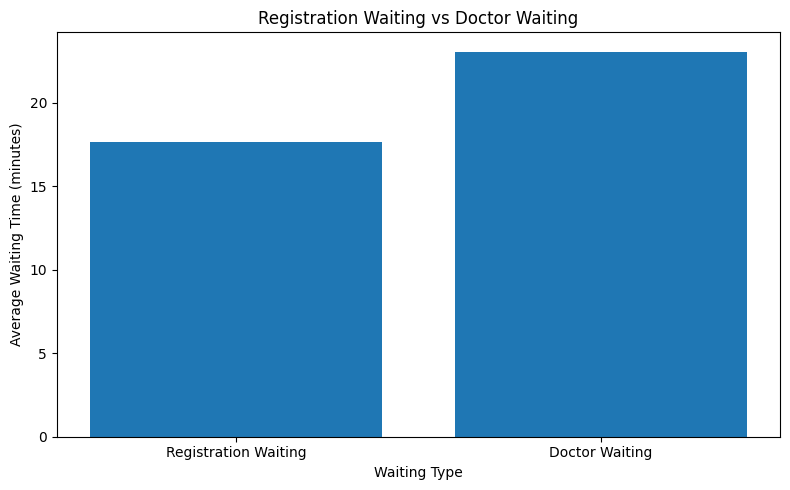

In [32]:
waiting_comparison = pd.DataFrame({
    'Waiting Type': [
        'Registration Waiting',
        'Doctor Waiting'
    ],
    'Average Minutes': [
        df['Registration_Waiting'].mean(),
        df['Doctor_Waiting'].mean()
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    waiting_comparison['Waiting Type'],
    waiting_comparison['Average Minutes']
)

plt.title('Registration Waiting vs Doctor Waiting')
plt.xlabel('Waiting Type')
plt.ylabel('Average Waiting Time (minutes)')

plt.tight_layout()
plt.show()

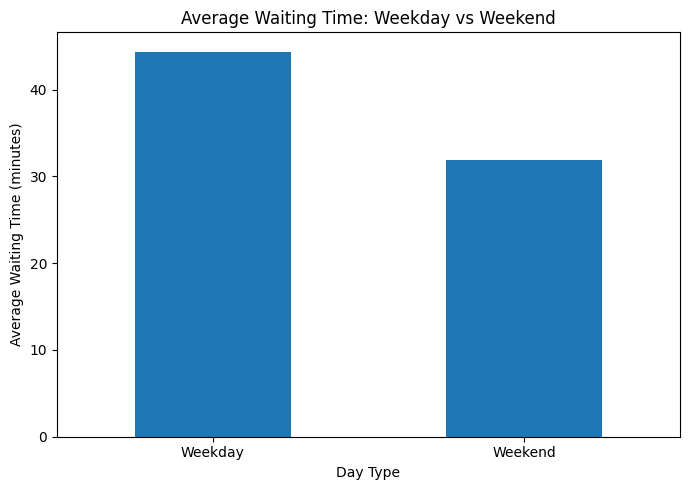

In [33]:
plt.figure(figsize=(7, 5))

day_analysis['Average_Waiting'].plot(kind='bar')

plt.title('Average Waiting Time: Weekday vs Weekend')
plt.xlabel('Day Type')
plt.ylabel('Average Waiting Time (minutes)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

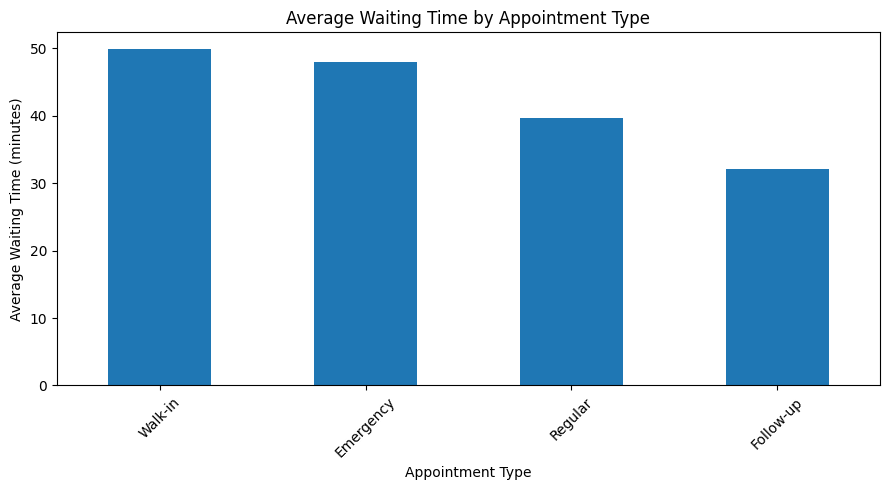

In [34]:
plt.figure(figsize=(9, 5))

appointment_analysis['Average_Waiting'].plot(kind='bar')

plt.title('Average Waiting Time by Appointment Type')
plt.xlabel('Appointment Type')
plt.ylabel('Average Waiting Time (minutes)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

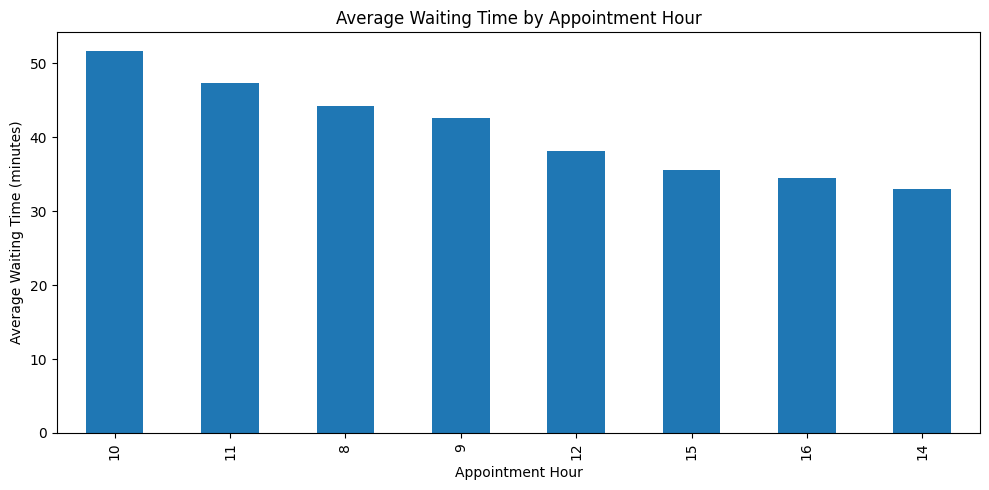

In [35]:
plt.figure(figsize=(10, 5))

hour_analysis['Average_Waiting'].plot(
    kind='bar'
)

plt.title('Average Waiting Time by Appointment Hour')
plt.xlabel('Appointment Hour')
plt.ylabel('Average Waiting Time (minutes)')

plt.tight_layout()
plt.show()

In [36]:
model_df = df.copy()

features = [
    'Department',
    'Doctor',
    'Day',
    'Appointment_Type',
    'Day_Type',
    'Appointment_Hour'
]

X = model_df[features].copy()

y = model_df['Total_Waiting']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
         Department      Doctor     Day Appointment_Type Day_Type  \
0       Orthopedics    Dr. Ravi  Monday        Follow-up  Weekday   
1               ENT   Dr. Vijay  Monday        Follow-up  Weekday   
2       Orthopedics  Dr. Anitha  Monday          Regular  Weekday   
3        Pediatrics   Dr. Divya  Monday          Walk-in  Weekday   
4  General Medicine   Dr. Meena  Monday          Regular  Weekday   

   Appointment_Hour  
0                 8  
1                 8  
2                 8  
3                10  
4                10  

Target:
0    58.0
1    17.0
2    60.0
3    35.0
4    67.0
Name: Total_Waiting, dtype: float64


In [37]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = [
    'Department',
    'Doctor',
    'Day',
    'Appointment_Type',
    'Day_Type'
]

encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

X.head()

,Department,Doctor,Day,Appointment_Type,Day_Type,Appointment_Hour
0,4,9,1,1,0,8
1,2,11,1,1,0,8
2,4,0,1,2,0,8
3,5,2,1,3,0,10
4,3,6,1,2,0,10


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80
Testing samples: 20


In [39]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [40]:
y_pred = rf_model.predict(X_test)

print("Actual values:")
print(y_test.values[:10])

print("\nPredicted values:")
print(y_pred[:10])

Actual values:
[46. 56. 35. 39. 46. 31. 46. 27. 38. 58.]

Predicted values:
[31.48  33.695 34.9   31.51  45.77  43.95  57.99  39.    46.335 32.72 ]


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("----------------------------")
print("MAE  :", round(mae, 2), "minutes")
print("RMSE :", round(rmse, 2), "minutes")
print("R²   :", round(r2, 2))

Model Evaluation
----------------------------
MAE  : 11.33 minutes
RMSE : 13.13 minutes
R²   : -0.04


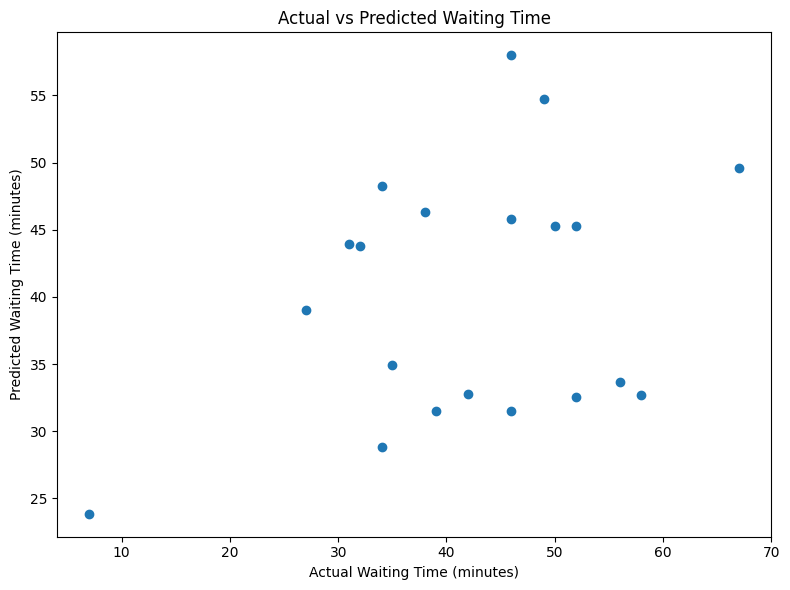

In [42]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Waiting Time (minutes)')
plt.ylabel('Predicted Waiting Time (minutes)')
plt.title('Actual vs Predicted Waiting Time')

plt.tight_layout()
plt.show()

In [43]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

importance

,Feature,Importance
3,Appointment_Type,0.218217
5,Appointment_Hour,0.215697
0,Department,0.191682
2,Day,0.131663
1,Doctor,0.126096
4,Day_Type,0.116646


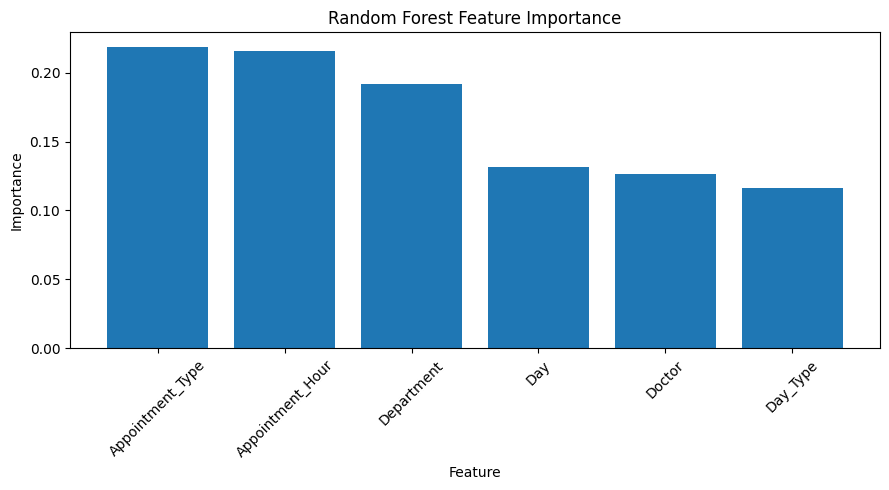

In [44]:
plt.figure(figsize=(9, 5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [45]:
print("========== KEY PROJECT RESULTS ==========")

print("\n1. Highest average waiting department:")
print(department_analysis['Average_Waiting'].idxmax(),
      "-",
      round(department_analysis['Average_Waiting'].max(), 2),
      "minutes")

print("\n2. Lowest average waiting department:")
print(department_analysis['Average_Waiting'].idxmin(),
      "-",
      round(department_analysis['Average_Waiting'].min(), 2),
      "minutes")

print("\n3. Average registration waiting:")
print(round(df['Registration_Waiting'].mean(), 2), "minutes")

print("\n4. Average doctor waiting:")
print(round(df['Doctor_Waiting'].mean(), 2), "minutes")

print("\n5. Average total waiting:")
print(round(df['Total_Waiting'].mean(), 2), "minutes")

print("\n6. Highest waiting appointment type:")
print(appointment_analysis['Average_Waiting'].idxmax())

print("\n7. Highest waiting day:")
print(day_of_week_analysis['Average_Waiting'].idxmax())

print("\n8. Model MAE:")
print(round(mae, 2), "minutes")

print("\n9. Model RMSE:")
print(round(rmse, 2), "minutes")

print("\n10. Model R2:")
print(round(r2, 2))

========== KEY PROJECT RESULTS ==========

1. Highest average waiting department:
Cardiology - 47.07 minutes

2. Lowest average waiting department:
Pediatrics - 29.71 minutes

3. Average registration waiting:
17.68 minutes

4. Average doctor waiting:
23.08 minutes

5. Average total waiting:
40.76 minutes

6. Highest waiting appointment type:
Walk-in

7. Highest waiting day:
Wednesday

8. Model MAE:
11.33 minutes

9. Model RMSE:
13.13 minutes

10. Model R2:
-0.04
